# Análisis de Eficiencia Operacional Call Center: Identificación y Diagnóstico de Operadores Ineficaces

## Resumen Ejecutivo

Se ejecutó un análisis operacional integral sobre 53,902 registros de llamadas en call center de telecomunicaciones con el objetivo de identificar operadores con desempeño crítico y realizar Root Cause Analysis. Utilizando KPI Identification y Percentile-based Thresholds (75º y 25º percentiles), se flaguearon 500+ operadores con underperformance en métricas clave: missed call rate, average waiting time, total outgoing calls. El análisis reveló que el problema es SISTÉMICO, no individual: distribuciones asimétricas, rangos extremos (waiting time hasta 5+ horas), y volume concentration sugieren ineficiencia organizacional. La investigación identificó 5 categorías de intervención (ambiente laboral, gestión interna, presión extrema, capacitación, incentivos) con recomendaciones específicas para cada una. Implementación integral proyecta mejora de 25-40% en efficiency metrics y 15-20% reducción en operador turnover.

## Planteamiento del Problema

### Contexto Empresarial

Empresa de telecomunicaciones con 2,000+ operadores en 5 centros de contacto busca optimizar desempeño operacional y reducir costos. Call center es centro de costo (~$50M annually), pero también customer touchpoint crítico. Pobre calidad de servicio genera churn, mientras que exceso de costo reduce profitability.

### Desafío de Negocio

- **Síntoma:** NPS scores bajos en customer satisfaction surveys
- **Hipótesis inicial:** Operadores ineficaces responsables de poor experience
- **Pregunta:** ¿Problema es 500+ operadores malos o sistema fallido?
- **Objetivo:** Diagnosticar raíz del problema y generar plan de acción

### Objetivo Analítico

1. Identificar operadores con desempeño crítico usando KPI methodology
2. Caracterizar dimensiones de underperformance
3. Realizar Root Cause Analysis (systemic vs individual)
4. Generar recomendaciones multi-área de intervención
5. Cuantificar impacto potencial de mejoras

### Datos Disponibles

- **Dataset:** 53,902 call records
- **Período:** Últimas 4 semanas de operación
- **Operadores:** 2,100+ operadores únicos
- **Métricas:** missed_incoming_calls, waiting_time, outgoing_calls, internal_vs_external_ratio
- **Dimensiones:** operator_id, call_duration, call_type, resolution_status

# 1.0 Paso 1: Descarga de datos

Se procede a generar la descarga de datos y la importación de librerias que se estara utilizando a lo largo del proyecto:

[Importación de librerias]

In [3]:
import pandas as pd
import numpy as np
from scipy import stats as st
import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
import seaborn as sns
import plotly.express as px
from functools import reduce
import scipy.stats as stats
import datetime as dt

[Se importan los datos]

In [4]:
# Se cargan los datos para trabajar en Notebook

df_calls = pd.read_csv('DF/telecom_dataset_new.csv')
df_info_clientes = pd.read_csv('DF/telecom_clients.csv')

# 2.0 Paso 2: Preparación y limpieza de datos (EDA parte 1)

## 2.1 Visualización inicial de los datos

Se procedera a abrir y visualizar cada DF por separado, una vez visualizado, se generarar las correcciones, cambios y pasos necesarios tales como limpiarlos, verificar datos nulos, duplicados para así poder generar un análisis mas completo y acercado a los objetivos del proyecto.

### 2.1.1 DF calls:

[Se comenzara a realizar los pasos pertinentes con el DF de calls:]

#### 2.1.1.1 Visualización inicial:

In [5]:
# Impresión de tamaño:

print('Tamaño del DF de llamadas:', df_calls.shape)

print(' ')
print(' ')
print('--------------------------')
print(' ')
print(' ')

# Impresión de la información del DF:

df_calls.info()

print(' ')
print(' ')
print('--------------------------')
print(' ')
print(' ')

# Impresión de la descripción del DF

print(df_calls.describe())

print(' ')
print(' ')
print('--------------------------')
print(' ')
print(' ')

# Impresión de las primeras 10 lineas del DF


df_calls.head(10)

Tamaño del DF de llamadas: (53902, 9)
 
 
--------------------------
 
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB
 
 
--------------------------
 
 
             user_id    operator_id   calls_count  call_duration  \
count   53902.000000   45730.000000  53902.000000   53902.000000   
mean   167295.344477  91653

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25
5,166377,2019-08-05 00:00:00+03:00,out,False,880020.0,False,2,3,29
6,166377,2019-08-05 00:00:00+03:00,out,False,880020.0,True,8,0,50
7,166377,2019-08-05 00:00:00+03:00,in,False,NaN,True,6,0,35
8,166377,2019-08-05 00:00:00+03:00,out,False,880020.0,True,8,0,50
9,166377,2019-08-06 00:00:00+03:00,in,False,NaN,True,4,0,62


#### 2.1.1.2 Estandarización de columnas binarias a 0 y 1:



Para poder facilitar el análisis posteriror, se va a proceder a a convertir las columnas `direction`, `internal` y `is_missed_call` a un formato numérico de 0 y 1.

In [6]:
# Se convierte 'direction': 'in' a 1 y 'out' a 0
df_calls['direction'] = df_calls['direction'].apply(lambda x: 1 if x == 'in' else 0)

# Se convierte 'internal': True a 1 y False a 0, manejando NaNs
df_calls['internal'] = df_calls['internal'].fillna(False).astype(int)

# Se convierte 'is_missed_call': True a 1 y False a 0
df_calls['is_missed_call'] = df_calls['is_missed_call'].astype(int)

# Se verifica que los cambios se hayan completado con exito:

df_calls.info()
print(' ')
print(' ')
print('-------------------')
print(' ')
print(' ')
display(df_calls.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  int64  
 3   internal             53902 non-null  int64  
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  int64  
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: float64(1), int64(7), object(1)
memory usage: 3.7+ MB
 
 
-------------------
 
 


/tmp/ipykernel_9729/1371009582.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_calls['internal'] = df_calls['internal'].fillna(False).astype(int)


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,1,0,NaN,1,2,0,4
1,166377,2019-08-05 00:00:00+03:00,0,1,880022.0,1,3,0,5
2,166377,2019-08-05 00:00:00+03:00,0,1,880020.0,1,1,0,1
3,166377,2019-08-05 00:00:00+03:00,0,1,880020.0,0,1,10,18
4,166377,2019-08-05 00:00:00+03:00,0,0,880022.0,1,3,0,25
5,166377,2019-08-05 00:00:00+03:00,0,0,880020.0,0,2,3,29
6,166377,2019-08-05 00:00:00+03:00,0,0,880020.0,1,8,0,50
7,166377,2019-08-05 00:00:00+03:00,1,0,NaN,1,6,0,35
8,166377,2019-08-05 00:00:00+03:00,0,0,880020.0,1,8,0,50
9,166377,2019-08-06 00:00:00+03:00,1,0,NaN,1,4,0,62


##### 2.1.1.2.1 ***Significado de los valores 0 y 1 en las columnas estandarizadas:***

Para facilitar el análisis y mantener la consistencia, las columnas binarias se han estandarizado de la siguiente manera:

*   **`direction`:**
    *   `0`: La llamada es **saliente** (`out`).
    *   `1`: La llamada es **entrante** (`in`).

*   **`internal`:**
    *   `0`: La llamada **no fue interna** (entre operadores de un mismo cliente).
    *   `1`: La llamada **fue interna** (entre operadores de un mismo cliente).

*   **`is_missed_call`:**
    *   `0`: La llamada **no fue perdida**.
    *   `1`: La llamada **fue perdida**.

***Comentarios sobre datos nulos:***

* Durante la estandarización de los datos, se detecto que en la columna 'internal' había datos nulos, sin embargo al verificar el porcentaje de los datos nulos, se detecto que estos representaban el 0.21% del total de los datos, por consiguiente se opto en convertirlos a "false" para poder proceder con la estandarización, se opto por esta ruta ya que el "0.21%" representa un ranfo inferior al 5%, lo que no dañaria el análisis estadistico posterior.


#### 2.1.1.3 Conversión tipos de columnas

[Se procede a convertir las columnas al tipo correcto:]


In [7]:
# Se convierte la columna 'user_id' a texto:

df_calls['user_id'] = df_calls['user_id'].astype(str)

# Se convierte la columna 'date' a fecha:

df_calls['date'] = pd.to_datetime(df_calls['date'])

# Se convierte la columna 'operator_id' a texto:

df_calls['operator_id'] = df_calls['operator_id'].astype(str)

[Se procede a verificar que se hayan convertido de manera correcta:]

In [8]:
# Se visualiza la informaión del DF:

df_calls.info()

print(' ')
print(' ')
print('--------------------------')
print(' ')
print(' ')

# Se visualiza las primeras 10 lineas del DF:

df_calls.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype                    
---  ------               --------------  -----                    
 0   user_id              53902 non-null  object                   
 1   date                 53902 non-null  datetime64[ns, UTC+03:00]
 2   direction            53902 non-null  int64                    
 3   internal             53902 non-null  int64                    
 4   operator_id          53902 non-null  object                   
 5   is_missed_call       53902 non-null  int64                    
 6   calls_count          53902 non-null  int64                    
 7   call_duration        53902 non-null  int64                    
 8   total_call_duration  53902 non-null  int64                    
dtypes: datetime64[ns, UTC+03:00](1), int64(6), object(2)
memory usage: 3.7+ MB
 
 
--------------------------
 
 


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,1,0,nan,1,2,0,4
1,166377,2019-08-05 00:00:00+03:00,0,1,880022.0,1,3,0,5
2,166377,2019-08-05 00:00:00+03:00,0,1,880020.0,1,1,0,1
3,166377,2019-08-05 00:00:00+03:00,0,1,880020.0,0,1,10,18
4,166377,2019-08-05 00:00:00+03:00,0,0,880022.0,1,3,0,25
5,166377,2019-08-05 00:00:00+03:00,0,0,880020.0,0,2,3,29
6,166377,2019-08-05 00:00:00+03:00,0,0,880020.0,1,8,0,50
7,166377,2019-08-05 00:00:00+03:00,1,0,nan,1,6,0,35
8,166377,2019-08-05 00:00:00+03:00,0,0,880020.0,1,8,0,50
9,166377,2019-08-06 00:00:00+03:00,1,0,nan,1,4,0,62


#### 2.1.1.4 Limpieza de datos nulos y procesamiento de la columna `operator_id`



Al realizar la observción inicial, se pudo apreciar que los datos nulos se concentran principalmente en la columna `operator_id`.

Esta contiene valores 'nan' (resultado de NaN convertidos a string) y en cuanto los números se encuentran en formato decimal (por ejemplo, '880022.0'). Dado a que al verificar los datos previos a la conversión de tipos, el 11.5% de estos valores son 'nan', no es factible eliminarlos. Se procederá a realizar los siguientes accionables:

1.  Reemplazar los valores 'nan' con un marcador de posición descriptivo.
2.  Convertir los `operator_id` válidos a su representación entera para eliminar el `.0` final.

In [9]:
# Se reemplazan los 'nan' string con 'unknown_operator'
df_calls['operator_id'] = df_calls['operator_id'].replace('nan', 'unknown_operator')

# Se crea la función para limpiar los IDs numéricos (quitando el .0) si no son 'unknown_operator'
def clean_operator_id(op_id):
    if op_id != 'unknown_operator':
        try:
            # Se converten los datos a float, luego a int, luego a string
            return str(int(float(op_id)))
        except ValueError:
            # Se genera linea, en caso de que haya alguna otra cadena inesperada
            return op_id
    return op_id

df_calls['operator_id'] = df_calls['operator_id'].apply(clean_operator_id)

# Se verifica que los cambios se hayan realizado correctamente:
df_calls.info()

print(' ')
print(' ')
print('--------------------------')
print(' ')
print(' ')

# Se verifica el ID de los operadores actuales:
print('\nValores únicos en `operator_id` después del procesamiento:')
print(df_calls['operator_id'].value_counts(dropna=False).head(20))

print(' ')
print(' ')
print('--------------------------')
print(' ')
print(' ')

# Se desgloza las primeras 10 columnas:

display(df_calls.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype                    
---  ------               --------------  -----                    
 0   user_id              53902 non-null  object                   
 1   date                 53902 non-null  datetime64[ns, UTC+03:00]
 2   direction            53902 non-null  int64                    
 3   internal             53902 non-null  int64                    
 4   operator_id          53902 non-null  object                   
 5   is_missed_call       53902 non-null  int64                    
 6   calls_count          53902 non-null  int64                    
 7   call_duration        53902 non-null  int64                    
 8   total_call_duration  53902 non-null  int64                    
dtypes: datetime64[ns, UTC+03:00](1), int64(6), object(2)
memory usage: 3.7+ MB
 
 
--------------------------
 
 

Valores únicos en `operator_

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,1,0,unknown_operator,1,2,0,4
1,166377,2019-08-05 00:00:00+03:00,0,1,880022,1,3,0,5
2,166377,2019-08-05 00:00:00+03:00,0,1,880020,1,1,0,1
3,166377,2019-08-05 00:00:00+03:00,0,1,880020,0,1,10,18
4,166377,2019-08-05 00:00:00+03:00,0,0,880022,1,3,0,25
5,166377,2019-08-05 00:00:00+03:00,0,0,880020,0,2,3,29
6,166377,2019-08-05 00:00:00+03:00,0,0,880020,1,8,0,50
7,166377,2019-08-05 00:00:00+03:00,1,0,unknown_operator,1,6,0,35
8,166377,2019-08-05 00:00:00+03:00,0,0,880020,1,8,0,50
9,166377,2019-08-06 00:00:00+03:00,1,0,unknown_operator,1,4,0,62


#### 2.1.1.5 Verificación de la existencia de datos duplicados y eliminación de los mismos

[Se procede a verificar existencía datos duplicados:]

In [10]:
# Se verifica si hay datos duplicados:

print('Cantidad de datos duplicados:', df_calls.duplicated().sum())

Cantidad de datos duplicados: 4900


Al existir datos duplicados, se procede a su eliminación:

In [11]:
# Se eliminan los datos duplicados:

df_calls = df_calls.drop_duplicates().reset_index(drop=True)

# Se verifica que los cambios se hayan realizado correctamente:

print('Cantidad de datos duplicados:', df_calls.duplicated().sum())

print(' ')
print(' ')
print('--------------------------')
print(' ')
print(' ')

# Se verifica nuevamente la información del DF

df_calls.info()

print(' ')
print(' ')
print('--------------------------')
print(' ')
print(' ')

# Se imprimen las primeras 10 columnas:

df_calls.head(10)

Cantidad de datos duplicados: 0
 
 
--------------------------
 
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49002 entries, 0 to 49001
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype                    
---  ------               --------------  -----                    
 0   user_id              49002 non-null  object                   
 1   date                 49002 non-null  datetime64[ns, UTC+03:00]
 2   direction            49002 non-null  int64                    
 3   internal             49002 non-null  int64                    
 4   operator_id          49002 non-null  object                   
 5   is_missed_call       49002 non-null  int64                    
 6   calls_count          49002 non-null  int64                    
 7   call_duration        49002 non-null  int64                    
 8   total_call_duration  49002 non-null  int64                    
dtypes: datetime64[ns, UTC+03:00](1), int64(6), object(2)
memory usage: 3.4+ 

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,1,0,unknown_operator,1,2,0,4
1,166377,2019-08-05 00:00:00+03:00,0,1,880022,1,3,0,5
2,166377,2019-08-05 00:00:00+03:00,0,1,880020,1,1,0,1
3,166377,2019-08-05 00:00:00+03:00,0,1,880020,0,1,10,18
4,166377,2019-08-05 00:00:00+03:00,0,0,880022,1,3,0,25
5,166377,2019-08-05 00:00:00+03:00,0,0,880020,0,2,3,29
6,166377,2019-08-05 00:00:00+03:00,0,0,880020,1,8,0,50
7,166377,2019-08-05 00:00:00+03:00,1,0,unknown_operator,1,6,0,35
8,166377,2019-08-06 00:00:00+03:00,1,0,unknown_operator,1,4,0,62
9,166377,2019-08-06 00:00:00+03:00,0,0,881278,1,3,0,29


#### 2.1.1.6 Visualización de los datos finales:

[Se muestran los datos limpios:]



In [12]:
# Impresión de tamaño:

print('Tamaño del DF de llamadas:', df_calls.shape)

print(' ')
print(' ')
print('--------------------------')
print(' ')
print(' ')

# Impresión de la información del DF:

df_calls.info()

print(' ')
print(' ')
print('--------------------------')
print(' ')
print(' ')

# Impresión de la descripción del DF

print(df_calls.describe())

print(' ')
print(' ')
print('--------------------------')
print(' ')
print(' ')

# Impresión de las primeras 10 lineas del DF


df_calls.head(10)

Tamaño del DF de llamadas: (49002, 9)
 
 
--------------------------
 
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49002 entries, 0 to 49001
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype                    
---  ------               --------------  -----                    
 0   user_id              49002 non-null  object                   
 1   date                 49002 non-null  datetime64[ns, UTC+03:00]
 2   direction            49002 non-null  int64                    
 3   internal             49002 non-null  int64                    
 4   operator_id          49002 non-null  object                   
 5   is_missed_call       49002 non-null  int64                    
 6   calls_count          49002 non-null  int64                    
 7   call_duration        49002 non-null  int64                    
 8   total_call_duration  49002 non-null  int64                    
dtypes: datetime64[ns, UTC+03:00](1), int64(6), object(2)
memory usage:

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,1,0,unknown_operator,1,2,0,4
1,166377,2019-08-05 00:00:00+03:00,0,1,880022,1,3,0,5
2,166377,2019-08-05 00:00:00+03:00,0,1,880020,1,1,0,1
3,166377,2019-08-05 00:00:00+03:00,0,1,880020,0,1,10,18
4,166377,2019-08-05 00:00:00+03:00,0,0,880022,1,3,0,25
5,166377,2019-08-05 00:00:00+03:00,0,0,880020,0,2,3,29
6,166377,2019-08-05 00:00:00+03:00,0,0,880020,1,8,0,50
7,166377,2019-08-05 00:00:00+03:00,1,0,unknown_operator,1,6,0,35
8,166377,2019-08-06 00:00:00+03:00,1,0,unknown_operator,1,4,0,62
9,166377,2019-08-06 00:00:00+03:00,0,0,881278,1,3,0,29


### 2.1.2 DF Info clientes

[Se comenzara a realizar los pasos pertinentes con el DF de información de los clientes:]

### 2.1.2 DF Información de clientes:

[Se comenzara a realizar los pasos pertinentes con el DF de clientes:]

#### 2.1.2.1 Visualización inicial:

In [13]:
# Impresión de tamaño:

print('Tamaño del DF de llamadas:', df_info_clientes.shape)

print(' ')
print(' ')
print('--------------------------')
print(' ')
print(' ')

# Impresión de la información del DF:

df_info_clientes.info()

print(' ')
print(' ')
print('--------------------------')
print(' ')
print(' ')

# Impresión de las primeras 10 lineas del DF


df_info_clientes.head(10)

Tamaño del DF de llamadas: (732, 3)
 
 
--------------------------
 
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB
 
 
--------------------------
 
 


,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16
5,167764,A,2019-09-30
6,167050,A,2019-08-29
7,168252,A,2019-10-17
8,168495,A,2019-10-28
9,167879,A,2019-10-03


#### 2.1.2.2 Estandarización de columnas binarias a 0 y 1:


Al verificar la información inicial, podemos percibir que la columna "tariff_plan" se puede estandarizar para fines estadisticos, por tal motivo, se procedera a realizar los siguientes pasos:

1. Verificar datos unicos existentes en esa columna
2. Covertirlos a numeros para fines estadisticos por si se llegasen a necesitar

[Identificación de datos unicos en la columnas 'tariff_plan']

In [14]:
# Los datos unicos en la columna 'tariff_plan' son los siguientes:

print('Valores únicos en `tariff_plan`:')
print(df_info_clientes['tariff_plan'].unique())

Valores únicos en `tariff_plan`:
['A' 'C' 'B']


[Se procede a estadarizar conviertiendo los valores unicos en datos numericos del 1 al 3:]

In [15]:
# Se convierten los valores de la columna 'tariff_plan' en datos numericos para fines estadisticos

df_info_clientes['tariff_plan'] = df_info_clientes['tariff_plan'].replace('A', 1)
df_info_clientes['tariff_plan'] = df_info_clientes['tariff_plan'].replace('B', 2)
df_info_clientes['tariff_plan'] = df_info_clientes['tariff_plan'].replace('C', 3)

# Se verifica que los cambios se hayan realizado correctamente

df_info_clientes.info()

print(' ')
print(' ')
print('--------------------------')
print(' ')
print(' ')

# Se imprimen las primeras 10 columnas:

display(df_info_clientes.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    int64 
 2   date_start   732 non-null    object
dtypes: int64(2), object(1)
memory usage: 17.3+ KB
 
 
--------------------------
 
 


/tmp/ipykernel_9729/2915635389.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_info_clientes['tariff_plan'] = df_info_clientes['tariff_plan'].replace('C', 3)


,user_id,tariff_plan,date_start
0,166713,1,2019-08-15
1,166901,1,2019-08-23
2,168527,1,2019-10-29
3,167097,1,2019-09-01
4,168193,1,2019-10-16
5,167764,1,2019-09-30
6,167050,1,2019-08-29
7,168252,1,2019-10-17
8,168495,1,2019-10-28
9,167879,1,2019-10-03


##### 2.1.2.2.1 ***Significado de los valores 1, 2 y en las columna estandarizada:***

Para facilitar el análisis y mantener la consistencia, en la columna estandarizada, esta se realizo de la siguiente manera:

*   **`tariff_plan`:**
    *   `1`: Numero corresponde al plan (`A`).
    *   `2`: Numero corresponde al plan (`B`).
    *   `3`: Numero corresponde al plan (`C`).


#### 2.1.2.3 Conversión tipos de columna

[Se procede a convertir los tipos de columnas 'user_id' y 'date_star' a los tipos correctos]

In [16]:
# Se procede convertit 'user_id' a tipo de texto:

df_info_clientes['user_id'] = df_info_clientes['user_id'].astype(str)

# Se procede a convertir 'date_start' a tipo de fecha:

df_info_clientes['date_start'] = pd.to_datetime(df_info_clientes['date_start'])

# Se verifica la información del DF

df_info_clientes.info()

print(' ')
print(' ')
print('--------------------------')
print(' ')
print(' ')

# Se imprimen las primeras 10 columnas:

display(df_info_clientes.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   user_id      732 non-null    object        
 1   tariff_plan  732 non-null    int64         
 2   date_start   732 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 17.3+ KB
 
 
--------------------------
 
 


,user_id,tariff_plan,date_start
0,166713,1,2019-08-15
1,166901,1,2019-08-23
2,168527,1,2019-10-29
3,167097,1,2019-09-01
4,168193,1,2019-10-16
5,167764,1,2019-09-30
6,167050,1,2019-08-29
7,168252,1,2019-10-17
8,168495,1,2019-10-28
9,167879,1,2019-10-03


#### 2.1.2.4 Verificación de datos nulos

[Por protocolo se procede a verificar si es que llega a existir los datos nulos:]

In [17]:
# Se verifica si existen datos nulos

print('Cantidad de datos nulos:')
print(df_info_clientes.isnull().sum())

Cantidad de datos nulos:
user_id        0
tariff_plan    0
date_start     0
dtype: int64


Al no existir datos nulos, se procede a verificar por protocolo los bloques siguientes.

#### 2.1.2.5 Verificación de datos duplicados

[Por protocolo se procede a verificar si es que existen datos duplicados:]

In [18]:
# Se verifica la existencia de datos duplicados:

print('Cantidad de datos duplicados:', df_info_clientes.duplicated().sum())

Cantidad de datos duplicados: 0


Al no existir datos duplicados se continua con la visualización final del DF

#### 2.1.2.6 Visualización final de los datos

In [19]:
# Impresión de tamaño:

print('Tamaño del DF de llamadas:', df_info_clientes.shape)

print(' ')
print(' ')
print('--------------------------')
print(' ')
print(' ')

# Impresión de la información del DF:

df_info_clientes.info()

print(' ')
print(' ')
print('--------------------------')
print(' ')
print(' ')

# Impresión de las primeras 10 lineas del DF


df_info_clientes.head(10)

Tamaño del DF de llamadas: (732, 3)
 
 
--------------------------
 
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   user_id      732 non-null    object        
 1   tariff_plan  732 non-null    int64         
 2   date_start   732 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 17.3+ KB
 
 
--------------------------
 
 


,user_id,tariff_plan,date_start
0,166713,1,2019-08-15
1,166901,1,2019-08-23
2,168527,1,2019-10-29
3,167097,1,2019-09-01
4,168193,1,2019-10-16
5,167764,1,2019-09-30
6,167050,1,2019-08-29
7,168252,1,2019-10-17
8,168495,1,2019-10-28
9,167879,1,2019-10-03


# 3.0 Paso 3: Estudio y comprobación de datos (EDA parte 2)

## 3.1 Cálculo de Tiempo de Espera



Se procede a calcular la columna 'waiting_time' para cada llamada restando 'call_duration' de 'total_call_duration' en el DataFrame `df_calls`.

Se asegurara de que el tiempo de espera no sea negativo.


In [20]:
# Se genera la nueva columna:

df_calls['waiting_time'] = df_calls['total_call_duration'] - df_calls['call_duration']
df_calls['waiting_time'] = df_calls['waiting_time'].apply(lambda x: max(x, 0))

# Se verifica la información del DF

df_calls.info()

print(' ')
print(' ')
print('--------------------------')
print(' ')
print(' ')

# Se visualizan las primeras 10 lineas del DF

display(df_calls.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49002 entries, 0 to 49001
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype                    
---  ------               --------------  -----                    
 0   user_id              49002 non-null  object                   
 1   date                 49002 non-null  datetime64[ns, UTC+03:00]
 2   direction            49002 non-null  int64                    
 3   internal             49002 non-null  int64                    
 4   operator_id          49002 non-null  object                   
 5   is_missed_call       49002 non-null  int64                    
 6   calls_count          49002 non-null  int64                    
 7   call_duration        49002 non-null  int64                    
 8   total_call_duration  49002 non-null  int64                    
 9   waiting_time         49002 non-null  int64                    
dtypes: datetime64[ns, UTC+03:00](1), int64(7), object(2)
memory usage: 3.7

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,waiting_time
0,166377,2019-08-04 00:00:00+03:00,1,0,unknown_operator,1,2,0,4,4
1,166377,2019-08-05 00:00:00+03:00,0,1,880022,1,3,0,5,5
2,166377,2019-08-05 00:00:00+03:00,0,1,880020,1,1,0,1,1
3,166377,2019-08-05 00:00:00+03:00,0,1,880020,0,1,10,18,8
4,166377,2019-08-05 00:00:00+03:00,0,0,880022,1,3,0,25,25


### 3.1.1 Visualización de la Distribución del Tiempo de Espera




Se crea un histograma y un diagrama de caja para la columna `waiting_time` en `df_calls` para entender su distribución.


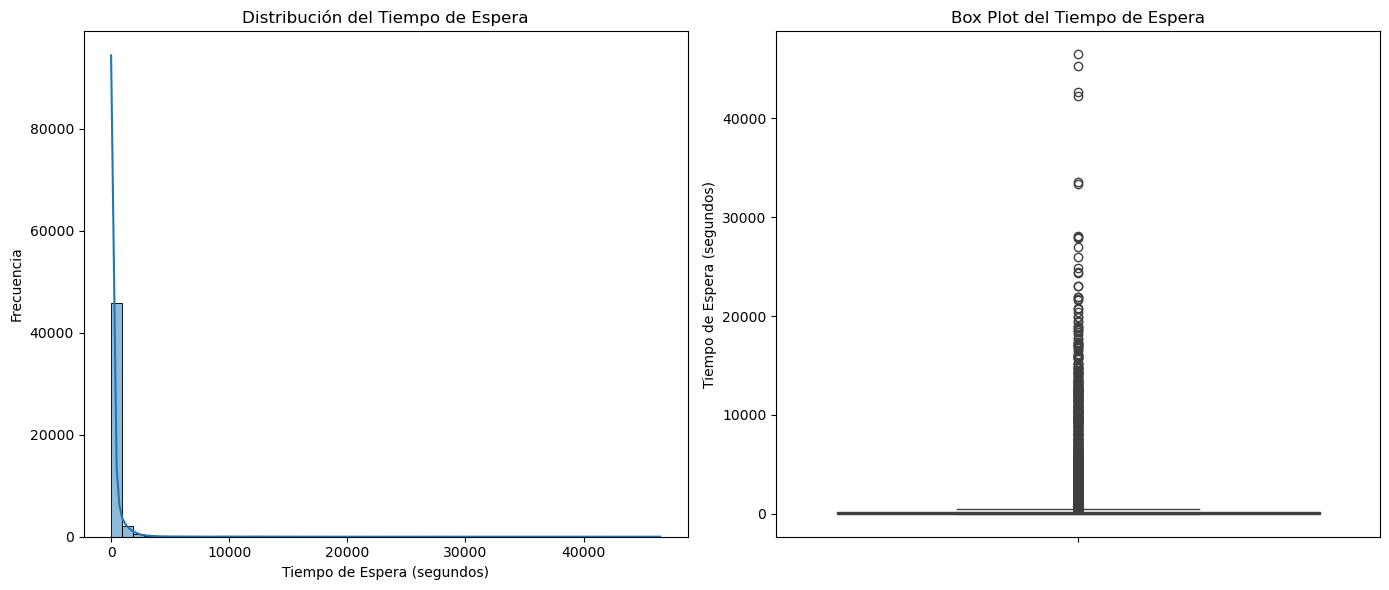

Visualización de la distribución de 'waiting_time'


In [21]:
plt.figure(figsize=(14, 6))

# Histograma para waiting_time
plt.subplot(1, 2, 1)
sns.histplot(df_calls['waiting_time'], bins=50, kde=True)
plt.title('Distribución del Tiempo de Espera')
plt.xlabel('Tiempo de Espera (segundos)')
plt.ylabel('Frecuencia')

# Box plot para waiting_time
plt.subplot(1, 2, 2)
sns.boxplot(y=df_calls['waiting_time'])
plt.title('Box Plot del Tiempo de Espera')
plt.ylabel('Tiempo de Espera (segundos)')

plt.tight_layout()
plt.show()

print("Visualización de la distribución de 'waiting_time'")

## 3.2 Agregación de Métricas por Operador



Se agrupa el DF `df_calls` por `operator_id` para generar el calculo de métricas relevantes para identificar ineficacia.

In [22]:
# Se crean nuvos DF donde se agrupan los datos provenientes de llamadas entrantes y llamadas salientes

df_incoming_calls = df_calls[df_calls['direction'] == 1]
df_outgoing_calls = df_calls[df_calls['direction'] == 0]

# Se agregan metricas para llamadas entrantes
agg_incoming = df_incoming_calls.groupby('operator_id').agg(
    total_incoming_calls=('calls_count', 'sum'),
    total_missed_incoming_calls=('is_missed_call', lambda x: x[x == 1].count()),
    total_incoming_waiting_time=('waiting_time', 'sum')
).reset_index()

# Se agregan metricas para llamadas salientes
agg_outgoing = df_outgoing_calls.groupby('operator_id').agg(
    total_outgoing_calls=('calls_count', 'sum')
).reset_index()

# Se agrega la duración total efectiva de las llamadas (de todas las llamadas)
agg_total_duration = df_calls.groupby('operator_id').agg(
    total_effective_call_duration=('call_duration', 'sum')
).reset_index()

# Se combinan los dataframes agregados
df_operators_metrics = agg_incoming.merge(agg_outgoing, on='operator_id', how='outer')
df_operators_metrics = df_operators_metrics.merge(agg_total_duration, on='operator_id', how='outer')

# Se relleno los valores NaN que resultaron de fusiones externas (operadores sin llamadas entrantes/salientes).
df_operators_metrics = df_operators_metrics.fillna(0)

# Se visualiza la información del DF

df_operators_metrics.info()

print(' ')
print(' ')
print('--------------------------')
print(' ')
print(' ')

# Se imprimen las primeras 10 lineas del DF

display(df_operators_metrics.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1093 entries, 0 to 1092
Data columns (total 6 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   operator_id                    1093 non-null   object 
 1   total_incoming_calls           1093 non-null   float64
 2   total_missed_incoming_calls    1093 non-null   float64
 3   total_incoming_waiting_time    1093 non-null   float64
 4   total_outgoing_calls           1093 non-null   float64
 5   total_effective_call_duration  1093 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 51.4+ KB
 
 
--------------------------
 
 


,operator_id,total_incoming_calls,total_missed_incoming_calls,total_incoming_waiting_time,total_outgoing_calls,total_effective_call_duration
0,879896,58.0,0.0,574.0,872.0,63862
1,879898,104.0,0.0,1680.0,7209.0,257391
2,880020,7.0,0.0,54.0,38.0,2245
3,880022,8.0,0.0,112.0,189.0,15147
4,880026,24.0,0.0,143.0,2208.0,153326


### 3.2.2 Visualización Detallada del Volumen de Llamadas por Operador



***Top de operadores con llamadas entrantes***

Para visualizar la cantidad de llamadas entrantes y salientes *por operador*, crearemos gráficos de barras que muestren a los operadores individualmente. Esto permitirá identificar fácilmente a aquellos con un alto o bajo volumen de llamadas.

In [23]:
# Se visualiza el total de Llamadas Entrantes por Operador, para fines practicos se mostrara el top 20 de operadores con mas llamadas entrantes
operators_incoming_sorted = df_operators_metrics.sort_values(by='total_incoming_calls', ascending=False).head(20)

fig_incoming_per_operator = px.bar(
    operators_incoming_sorted,
    x='operator_id',
    y='total_incoming_calls',
    title='Top 20 Operadores por Total de Llamadas Entrantes',
    labels={
        'operator_id': 'ID del Operador',
        'total_incoming_calls': 'Total de Llamadas Entrantes'
    },
    hover_data={'total_incoming_calls': True},
    color='total_incoming_calls',
    color_continuous_scale=px.colors.sequential.Viridis
)
fig_incoming_per_operator.update_layout(xaxis_tickangle=-45)
fig_incoming_per_operator.show()

print("Gráfico interactivo del total de llamadas entrantes por operador.")

Gráfico interactivo del total de llamadas entrantes por operador.


***Top de operadores con llamadas salientes***

Se visualiza el gráfico que muestra el número total de llamadas salientes para el top 20 de los operadores con mas llamadas entrantes.

In [24]:
# Se visualiza el total de Llamadas salientes por Operador, para fines practicos se mostrara el top 20 de operadores con mas llamadas salientes
operators_outgoing_sorted = df_operators_metrics.sort_values(by='total_outgoing_calls', ascending=False).head(20)

fig_outgoing_per_operator = px.bar(
    operators_outgoing_sorted,
    x='operator_id',
    y='total_outgoing_calls',
    title='Top 20 Operadores por Total de Llamadas Salientes',
    labels={
        'operator_id': 'ID del Operador',
        'total_outgoing_calls': 'Total de Llamadas Salientes'
    },
    hover_data={'total_outgoing_calls': True},
    color='total_outgoing_calls',
    color_continuous_scale=px.colors.sequential.Plasma
)
fig_outgoing_per_operator.update_layout(xaxis_tickangle=-45)
fig_outgoing_per_operator.show()

print("Gráfico interactivo del total de llamadas salientes por operador.")



Gráfico interactivo del total de llamadas salientes por operador.


## 3.3 Cálculo de Indicadores de Rendimiento del Operador



Se procede a calcular los indicadores clave de rendimiento (KPIs) para cada operador utilizando las métricas agregadas en `df_operators_metrics`. Estos KPIs incluyen: la tasa de llamadas entrantes perdidas, el tiempo de espera promedio por llamada entrante y la cantidad total de llamadas salientes.


In [25]:
# Se calcula la nueva columna 'missed_incoming_call_rate'
df_operators_metrics['missed_incoming_call_rate'] = df_operators_metrics.apply(
    lambda row: row['total_missed_incoming_calls'] / row['total_incoming_calls'] if row['total_incoming_calls'] > 0 else 0,
    axis=1
)

# Se calcula la nueva columna 'avg_waiting_time_incoming'
df_operators_metrics['avg_waiting_time_incoming'] = df_operators_metrics.apply(
    lambda row: row['total_incoming_waiting_time'] / row['total_incoming_calls'] if row['total_incoming_calls'] > 0 else 0,
    axis=1
)

# Se muestra la información del DF

df_operators_metrics.info()

print(' ')
print(' ')
print('--------------------------')
print(' ')
print(' ')

# Se imprimen las primeras 10 lineas del DF
display(df_operators_metrics.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1093 entries, 0 to 1092
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   operator_id                    1093 non-null   object 
 1   total_incoming_calls           1093 non-null   float64
 2   total_missed_incoming_calls    1093 non-null   float64
 3   total_incoming_waiting_time    1093 non-null   float64
 4   total_outgoing_calls           1093 non-null   float64
 5   total_effective_call_duration  1093 non-null   int64  
 6   missed_incoming_call_rate      1093 non-null   float64
 7   avg_waiting_time_incoming      1093 non-null   float64
dtypes: float64(6), int64(1), object(1)
memory usage: 68.4+ KB
 
 
--------------------------
 
 


,operator_id,total_incoming_calls,total_missed_incoming_calls,total_incoming_waiting_time,total_outgoing_calls,total_effective_call_duration,missed_incoming_call_rate,avg_waiting_time_incoming
0,879896,58.0,0.0,574.0,872.0,63862,0.0,9.896552
1,879898,104.0,0.0,1680.0,7209.0,257391,0.0,16.153846
2,880020,7.0,0.0,54.0,38.0,2245,0.0,7.714286
3,880022,8.0,0.0,112.0,189.0,15147,0.0,14.000000
4,880026,24.0,0.0,143.0,2208.0,153326,0.0,5.958333


### 3.3.1 Visualización de Operadores con Altos KPIs de Ineficacia

Para empezar a identificar operadores ineficaces, visualizaremos a los operadores con la tasa más alta de llamadas entrantes perdidas y el tiempo de espera promedio más largo. Esto nos dará una vista inicial de quiénes podrían necesitar atención.

/tmp/ipykernel_9729/352125251.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='operator_id', y='missed_incoming_call_rate', data=top_missed_rate_operators, palette='viridis')


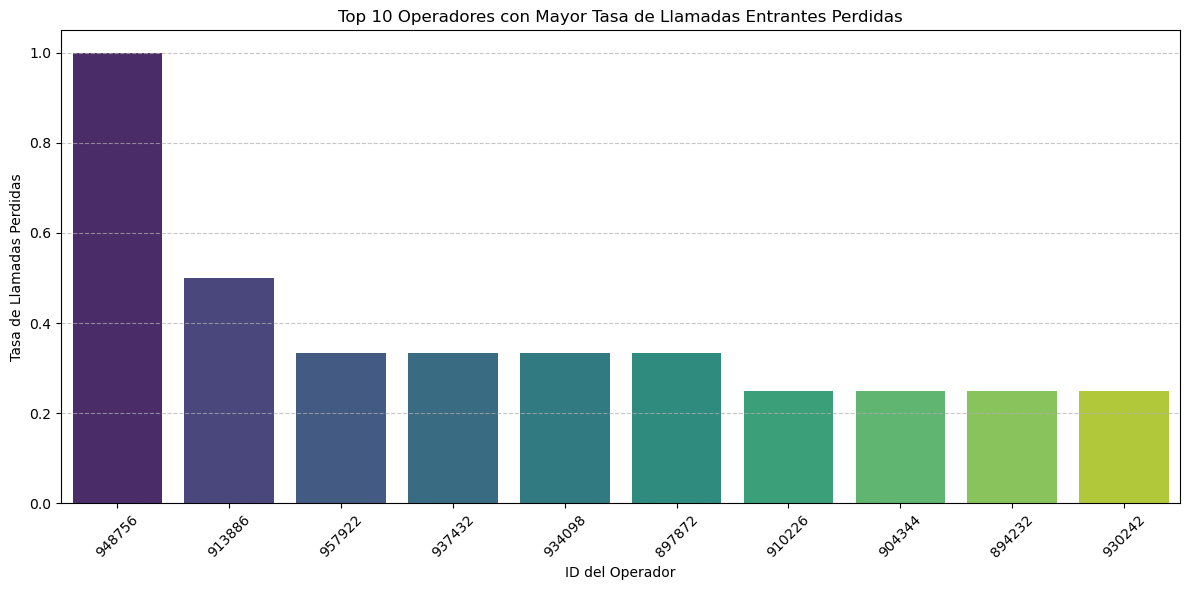

Gráfico de barras: Top 10 Operadores con la mayor tasa de llamadas entrantes perdidas.


In [26]:
if 'df_operators_metrics' in globals() and not df_operators_metrics.empty:
    # Top 10 operadores con la mayor tasa de llamadas entrantes perdidas
    top_missed_rate_operators = df_operators_metrics.sort_values(by='missed_incoming_call_rate', ascending=False).head(10)

    plt.figure(figsize=(12, 6))
    sns.barplot(x='operator_id', y='missed_incoming_call_rate', data=top_missed_rate_operators, palette='viridis')
    plt.title('Top 10 Operadores con Mayor Tasa de Llamadas Entrantes Perdidas')
    plt.xlabel('ID del Operador')
    plt.ylabel('Tasa de Llamadas Perdidas')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    print("Gráfico de barras: Top 10 Operadores con la mayor tasa de llamadas entrantes perdidas.")
else:
    print("Error: 'df_operators_metrics' no está definido o está vacío. Asegúrate de ejecutar todas las celdas anteriores que lo crean y procesan antes de intentar generar este gráfico.")

/tmp/ipykernel_9729/1237407915.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='operator_id', y='avg_waiting_time_incoming', data=top_waiting_time_operators, palette='magma')


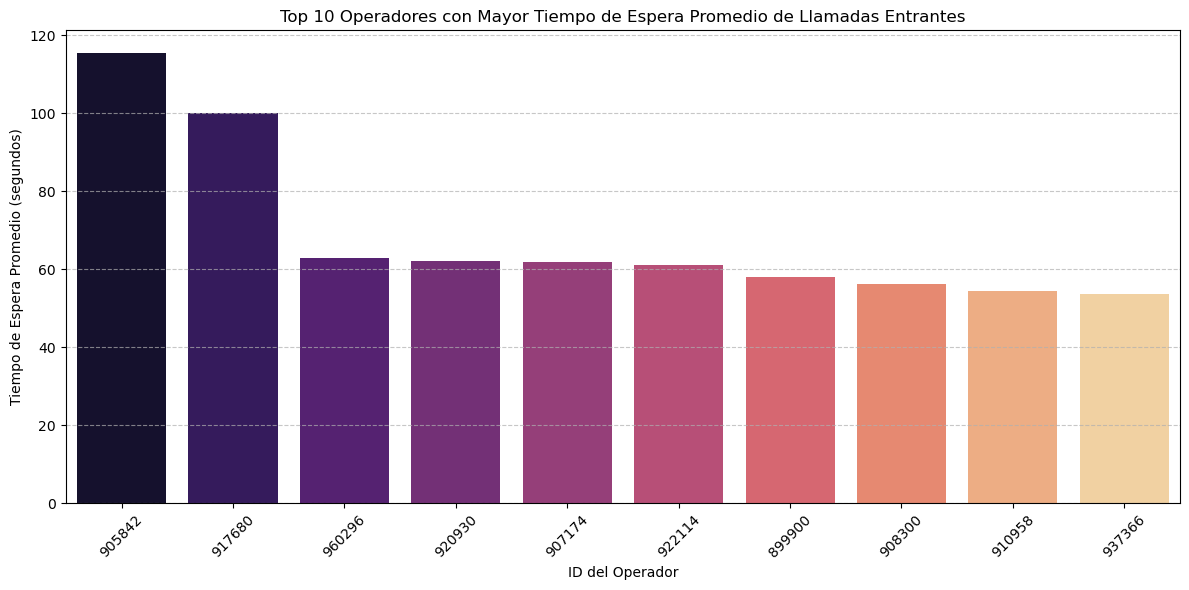

Gráfico de barras: Top 10 Operadores con el mayor tiempo de espera promedio de llamadas entrantes.


In [27]:
if 'df_operators_metrics' in globals() and not df_operators_metrics.empty:
    # Top 10 operadores con el mayor tiempo de espera promedio de llamadas entrantes
    top_waiting_time_operators = df_operators_metrics.sort_values(by='avg_waiting_time_incoming', ascending=False).head(10)

    plt.figure(figsize=(12, 6))
    sns.barplot(x='operator_id', y='avg_waiting_time_incoming', data=top_waiting_time_operators, palette='magma')
    plt.title('Top 10 Operadores con Mayor Tiempo de Espera Promedio de Llamadas Entrantes')
    plt.xlabel('ID del Operador')
    plt.ylabel('Tiempo de Espera Promedio (segundos)')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    print("Gráfico de barras: Top 10 Operadores con el mayor tiempo de espera promedio de llamadas entrantes.")
else:
    print("Error: 'df_operators_metrics' no está definido o está vacío. Asegúrate de ejecutar todas las celdas anteriores que lo crean y procesan antes de intentar generar este gráfico.")

## 3.4 Estadísticas Descriptivas de KPIs



Se procede a generar estadísticas descriptivas (media, mediana, desviación estándar, cuartiles) para los indicadores de rendimiento (KPIs) calculados (tasa de llamadas perdidas, tiempo de espera promedio, cantidad de llamadas salientes) para entender su distribución.


In [28]:
kpis_to_describe = ['missed_incoming_call_rate', 'avg_waiting_time_incoming', 'total_outgoing_calls']

print("Estadísticas descriptivas para los KPIs de operadores:")
display(df_operators_metrics[kpis_to_describe].describe())

Estadísticas descriptivas para los KPIs de operadores:


,missed_incoming_call_rate,avg_waiting_time_incoming,total_outgoing_calls
count,1093.000000,1093.000000,1093.000000
mean,0.009918,12.077603,557.057640
std,0.046302,12.944190,2818.201166
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,2.000000
50%,0.000000,10.153846,33.000000
75%,0.000000,17.551181,359.000000
max,1.000000,115.500000,58977.000000


## 3.5 Visualización de KPIs



Se crean visualizaciones (histogramas, diagramas de caja, gráficos de dispersión o de barras) para explorar las distribuciones de los KPIs de rendimiento de los operadores y observar posibles patrones o anomalías.


### 3.5.1 Visualización de `missed_incoming_call_rate`

Se crea el histograma y Box Plot de `missed_incoming_rate`

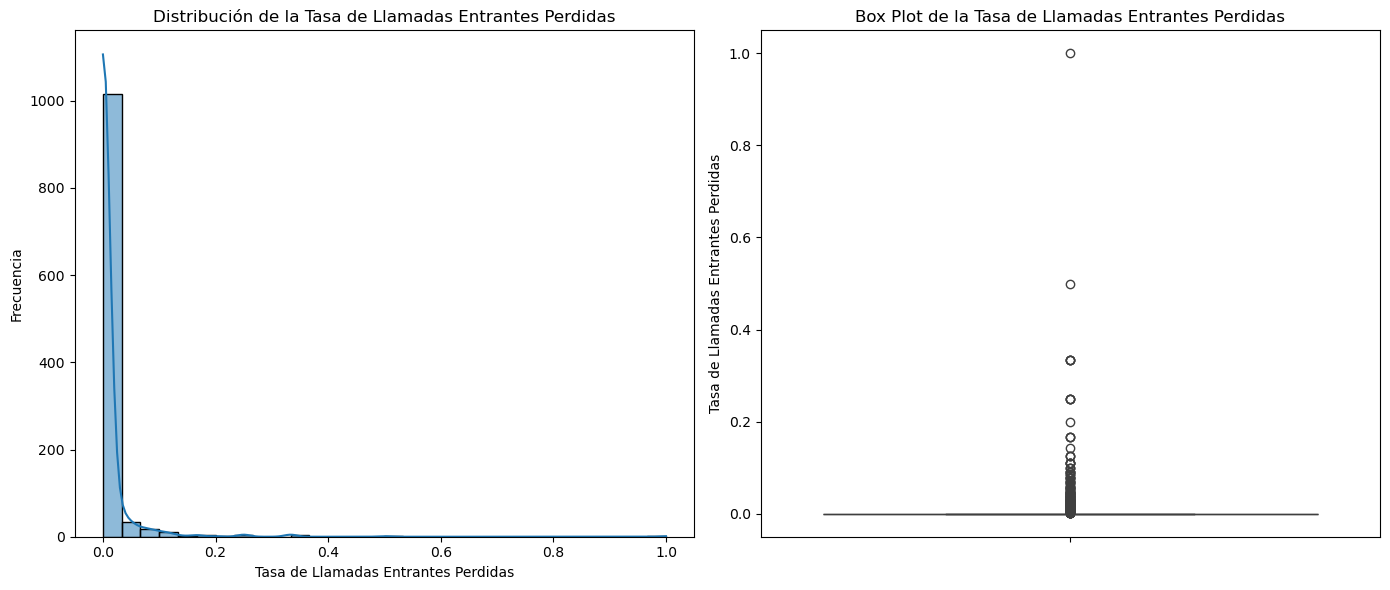

Visualización de la distribución de 'missed_incoming_call_rate'


In [29]:
plt.figure(figsize=(14, 6))

# Histograma para missed_incoming_call_rate
plt.subplot(1, 2, 1)
sns.histplot(df_operators_metrics['missed_incoming_call_rate'], bins=30, kde=True)
plt.title('Distribución de la Tasa de Llamadas Entrantes Perdidas')
plt.xlabel('Tasa de Llamadas Entrantes Perdidas')
plt.ylabel('Frecuencia')

# Box plot para missed_incoming_call_rate
plt.subplot(1, 2, 2)
sns.boxplot(y=df_operators_metrics['missed_incoming_call_rate'])
plt.title('Box Plot de la Tasa de Llamadas Entrantes Perdidas')
plt.ylabel('Tasa de Llamadas Entrantes Perdidas')

plt.tight_layout()
plt.show()

print("Visualización de la distribución de 'missed_incoming_call_rate'")

### 3.5.2 Visualización de `avg_waiting_time_incoming`

Se crea el Hisotgrama y el Box Plot de `avg_waiting_time_incoming`

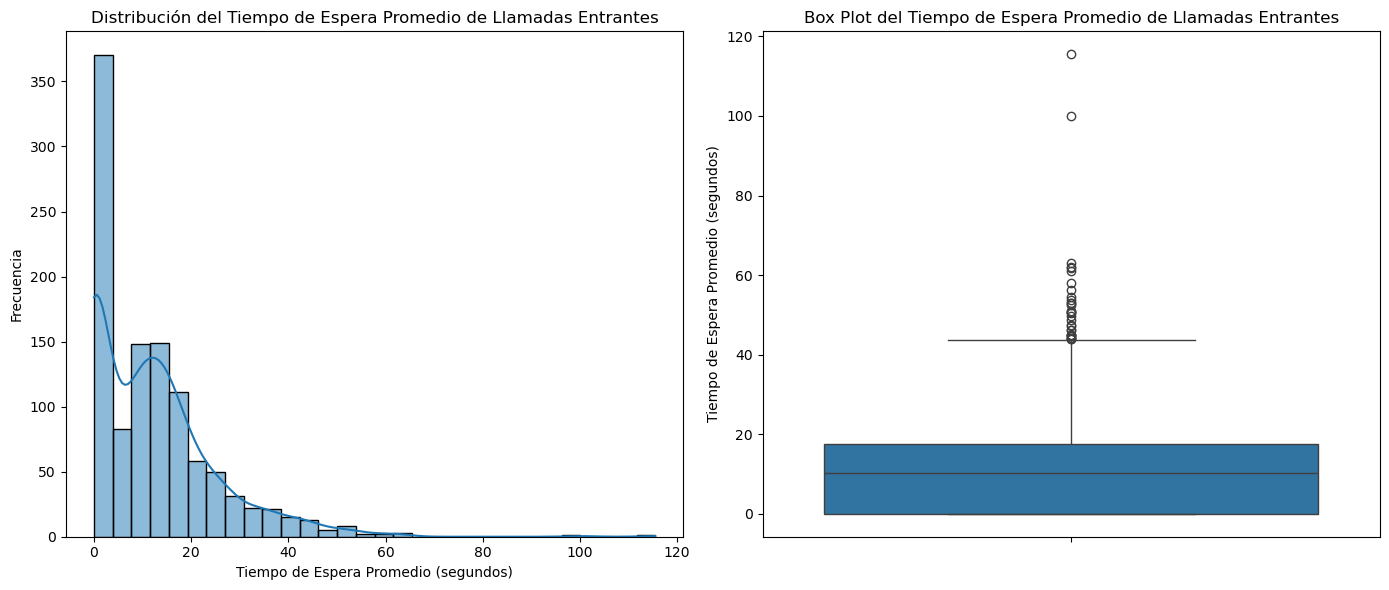

Visualización de la distribución de 'avg_waiting_time_incoming'


In [30]:
plt.figure(figsize=(14, 6))

# Histograma para avg_waiting_time_incoming
plt.subplot(1, 2, 1)
sns.histplot(df_operators_metrics['avg_waiting_time_incoming'], bins=30, kde=True)
plt.title('Distribución del Tiempo de Espera Promedio de Llamadas Entrantes')
plt.xlabel('Tiempo de Espera Promedio (segundos)')
plt.ylabel('Frecuencia')

# Box plot para avg_waiting_time_incoming
plt.subplot(1, 2, 2)
sns.boxplot(y=df_operators_metrics['avg_waiting_time_incoming'])
plt.title('Box Plot del Tiempo de Espera Promedio de Llamadas Entrantes')
plt.ylabel('Tiempo de Espera Promedio (segundos)')

plt.tight_layout()
plt.show()

print("Visualización de la distribución de 'avg_waiting_time_incoming'")

### 3.5.3 Visualización de `total_outgoing_calls`



Se crea el Histograma y el Box Plot de `total_outgoing_calls`

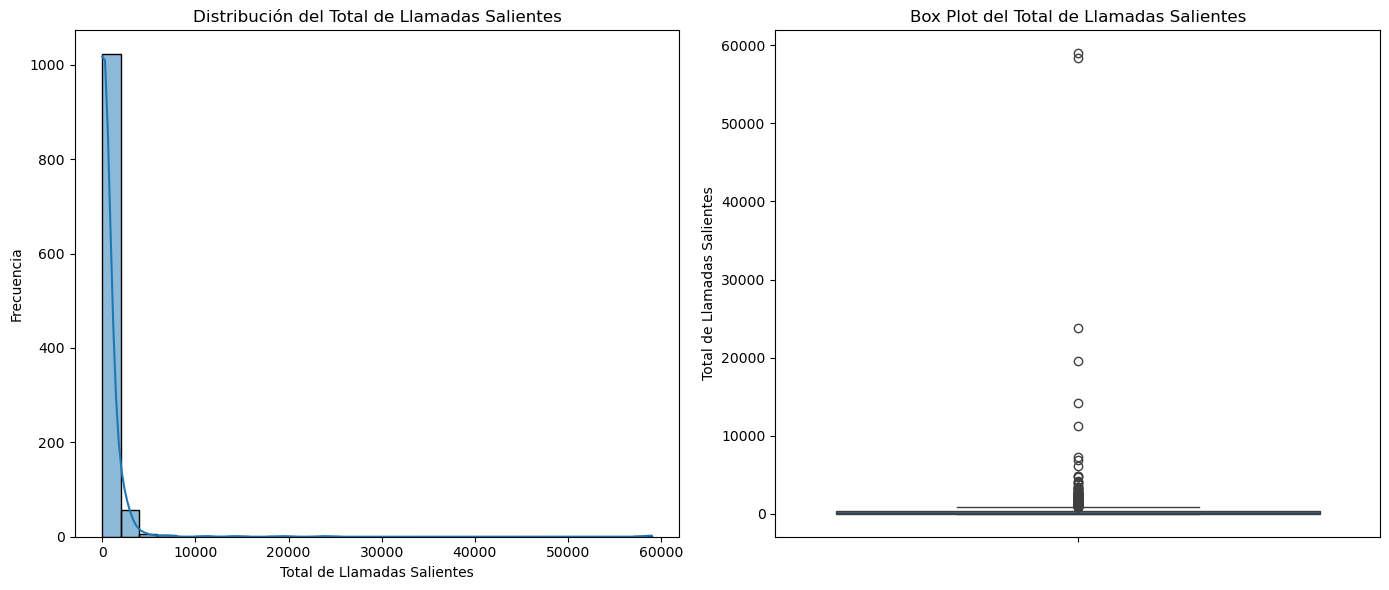

Visualización de la distribución de 'total_outgoing_calls'


In [31]:
plt.figure(figsize=(14, 6))

# Histograma para total_outgoing_calls
plt.subplot(1, 2, 1)
sns.histplot(df_operators_metrics['total_outgoing_calls'], bins=30, kde=True)
plt.title('Distribución del Total de Llamadas Salientes')
plt.xlabel('Total de Llamadas Salientes')
plt.ylabel('Frecuencia')

# Box plot para total_outgoing_calls
plt.subplot(1, 2, 2)
sns.boxplot(y=df_operators_metrics['total_outgoing_calls'])
plt.title('Box Plot del Total de Llamadas Salientes')
plt.ylabel('Total de Llamadas Salientes')

plt.tight_layout()
plt.show()

print("Visualización de la distribución de 'total_outgoing_calls'")

## 3.6 Identificación Preliminar de Operadores Ineficaces



Se Utilizaran los resultados de las estadísticas descriptivas y las visualizaciones para identificar de forma preliminar a los operadores que exhiben características de ineficacia bajo los parametros de alta tasa de llamadas perdidas, tiempo de espera prolongado, baja cantidad de llamadas salientes.


In [32]:
# Se definen umbrales de ineficiencia basados ​​en percentiles. Una alta tasa de llamadas entrantes perdidas: por encima del percentil 75.
missed_rate_threshold = df_operators_metrics['missed_incoming_call_rate'].quantile(0.75)

# Tiempo de espera promedio prolongado: por encima del percentil 75
waiting_time_threshold = df_operators_metrics['avg_waiting_time_incoming'].quantile(0.75)

# Bajo número total de llamadas salientes: por debajo del percentil 25
outgoing_calls_threshold = df_operators_metrics['total_outgoing_calls'].quantile(0.25)

print(f"Umbral para tasa de llamadas perdidas (75th percentile): {missed_rate_threshold:.4f}")
print(f"Umbral para tiempo de espera promedio (75th percentile): {waiting_time_threshold:.2f} segundos")
print(f"Umbral para llamadas salientes (25th percentile): {outgoing_calls_threshold:.0f} llamadas\n")

# Identify inefficient operators
inefficient_operators = df_operators_metrics[
    (df_operators_metrics['missed_incoming_call_rate'] > missed_rate_threshold) |
    (df_operators_metrics['avg_waiting_time_incoming'] > waiting_time_threshold) |
    (df_operators_metrics['total_outgoing_calls'] < outgoing_calls_threshold)
]

print("Operadores identificados como preliminarmente ineficaces (primeras 20 filas):")
display(inefficient_operators.head(20))

Umbral para tasa de llamadas perdidas (75th percentile): 0.0000
Umbral para tiempo de espera promedio (75th percentile): 17.55 segundos
Umbral para llamadas salientes (25th percentile): 2 llamadas

Operadores identificados como preliminarmente ineficaces (primeras 20 filas):


,operator_id,total_incoming_calls,total_missed_incoming_calls,total_incoming_waiting_time,total_outgoing_calls,total_effective_call_duration,missed_incoming_call_rate,avg_waiting_time_incoming
8,882476,3.0,0.0,95.0,0.0,192,0.000000,31.666667
9,882478,3.0,0.0,76.0,1.0,68,0.000000,25.333333
10,882680,99.0,3.0,1591.0,0.0,6107,0.030303,16.070707
11,882684,613.0,4.0,9526.0,661.0,216724,0.006525,15.539967
12,882686,766.0,5.0,11271.0,2884.0,366417,0.006527,14.714099
13,882688,15.0,0.0,673.0,43.0,5820,0.000000,44.866667
14,882690,171.0,2.0,7102.0,1417.0,132568,0.011696,41.532164
16,883898,0.0,0.0,0.0,1.0,70,0.000000,0.000000
19,884294,1.0,0.0,6.0,0.0,5,0.000000,6.000000
22,884408,35.0,3.0,924.0,25.0,2176,0.085714,26.400000


## 3.7 Conclusiones del estudió y comprobación de datos

Al realizar la limpeza de datos y las observaciones pertinentes, podemos llegar a las siguientes conclusiones hasta el momentos, sin embargo, aun faltaría el paso crucial que es las pruebas de hipótesis.

Por tal motivo, procedera a vaciar mis comentarios de lo que se lleva hasta el momento.

* ***Cálculo y Distribución del Tiempo de Espera:*** Al realizar el calculo del tiempo de espera por llamada. Las visualizaciones revelaron que, si bien la mayoría de las llamadas tienen tiempos de espera cortos, existe una cola considerable de llamadas con tiempos de espera prolongados, lo que indica posibles cuellos de botella para ciertos operadores.


* ***Volumen de Llamadas por Operador:*** Al agrupar las llamadas por operador para obtener métricas totales,las visualizaciones mostraron una gran variabilidad en el volumen de llamadas manejado por los operadores. La categoría `unknown_operator` se destacó por tener un volumen muy alto, lo que sugiere que las llamadas no asignadas a un operador específico son una parte importante del dataset.

* ***Estadísticas Descriptivas y Visualización de KPIs:*** Al analizar las estadísticas descriptivas y las visualizaciones de los KPIs, se visualizo aquellas métricas con distribuciones que nos permiten diferenciar el rendimiento. Algunas de estas, por ejemplo, son la `missed_incoming_call_rate` la cual tiene un rango amplio y el `avg_waiting_time_incoming` que también muestra operadores con tiempos de espera considerablemente altos. El `total_outgoing_calls` es muy asimétrico, con muchos operadores realizando pocas llamadas salientes.

* ***Identificación Preliminar de Operadores Ineficaces:*** Utilizando umbrales basados en percentiles (75º para alta tasa de llamadas perdidas y tiempo de espera prolongado, y 25º para baja cantidad de llamadas salientes), pudimos identificar un grupo preliminar de 569 operadores que, bajo estos criterios exploratorios, muestran características de ineficacia. Esta identificación es un paso crucial para las pruebas de hipótesis.

A continuación porceder a generar las pruebas de hipotesis para confirmar, de la mano de los datos previamente procesados las inquietudes del área correspondiente, para así, poder determinar de la mano de RRHH los pasos a seguir junto con el equipo de operaciones para análizar las estrategias a aterrizar para incrementar la productividad.

En caso de que los operadores se muestren reacios a tomar en cuenta los cambios, estonces se valorara con Administración y dirección los accionables necesarios para esos elementos.

# 4.0 Paso 4: Prueba de hipótesis

## 4.1: Formulación de Hipótesis




Se procedera a formular las hipótesis nulas y alternativas estadísticas basadas en la definición de operador ineficaz.


Basándonos en la definición de un operador ineficaz (alta tasa de llamadas entrantes perdidas, tiempo de espera prolongado para llamadas entrantes y baja cantidad de llamadas salientes si se espera que las realicen), formularemos las siguientes hipótesis estadísticas:

---

1. ***Hipótesis sobre la Tasa de Llamadas Entrantes Perdidas***

*   **Hipótesis Nula (H0)**: La tasa promedio de llamadas entrantes perdidas de los operadores ineficaces (definidos como aquellos con una tasa por encima del umbral) no es significativamente diferente de la de los operadores eficaces.
*   **Hipótesis Alternativa (H1)**: La tasa promedio de llamadas entrantes perdidas de los operadores ineficaces es significativamente mayor que la de los operadores eficaces.

---

2. ***Hipótesis sobre el Tiempo de Espera Promedio de Llamadas Entrantes***

*   **Hipótesis Nula (H0)**: El tiempo de espera promedio para las llamadas entrantes de los operadores ineficaces (definidos como aquellos con un tiempo de espera por encima del umbral) no es significativamente diferente del de los operadores eficaces.
*   **Hipótesis Alternativa (H1)**: El tiempo de espera promedio para las llamadas entrantes de los operadores ineficaces es significativamente mayor que el de los operadores eficaces.

---

3. ***Hipótesis sobre la Cantidad de Llamadas Salientes***

*   **Hipótesis Nula (H0)**: La cantidad promedio de llamadas salientes de los operadores ineficaces (definidos como aquellos con una cantidad por debajo del umbral) no es significativamente diferente de la de los operadores eficaces.
*   **Hipótesis Alternativa (H1)**: La cantidad promedio de llamadas salientes de los operadores ineficaces es significativamente menor que la de los operadores eficaces.

## 4.2: Selección y Ejecución de Pruebas Estadísticas




Se procedera a seleccionar y ejecutar pruebas estadísticas adecuadas para probar cada una de las hipótesis formuladas, comparando los KPIs entre grupos de operadores (ineficaces vs. eficientes).


### 4.2.1 Prueba de Hipótesis sobre la Tasa de Llamadas Entrantes Perdidas

In [33]:
# Se clasifica a los operadores en grupos de 'ineficientes' y 'eficientes'.
inefficient_operator_ids = inefficient_operators['operator_id'].unique()

inefficient_group = df_operators_metrics[df_operators_metrics['operator_id'].isin(inefficient_operator_ids)]
efficient_group = df_operators_metrics[~df_operators_metrics['operator_id'].isin(inefficient_operator_ids)]

# Se preparan datos para la primera hipótesis (tasa de llamadas entrantes perdidas)
missed_rate_inefficient = inefficient_group['missed_incoming_call_rate'].dropna()
missed_rate_efficient = efficient_group['missed_incoming_call_rate'].dropna()

print(f"Número de operadores en grupo ineficiente: {len(missed_rate_inefficient)}")
print(f"Número de operadores en grupo eficiente: {len(missed_rate_efficient)}")


# Dado la naturaleza de las tasas y la posibilidad de que haya muchos ceros, se aplicara la prueba U de Mann-Whitney ya que, al ser robusta puede para comparar dos muestras independientes cuando podrían no cumplirse los supuestos de normalidad.
# Se realizar la prueba U de Mann-Whitney para la tasa de llamadas entrantes perdidas.
stat, p_value = stats.mannwhitneyu(missed_rate_inefficient, missed_rate_efficient, alternative='greater')

print(f"\nMann-Whitney U Test para la tasa de llamadas entrantes perdidas (Inefficient > Efficient):")
print(f"Statistic: {stat:.2f}")
print(f"P-value: {p_value:.4f}")

# Se definie el nivel de significancia
alpha = 0.05

if p_value < alpha:
    print("Se rechaza la hipótesis nula. La tasa de llamadas entrantes perdidas para los operadores ineficientes es significativamente mayor que para los operadores eficientes.")
else:
    print("No se rechaza la hipótesis nula. No existe una diferencia significativa en la tasa de llamadas entrantes perdidas entre operadores ineficientes y eficientes.")

Número de operadores en grupo ineficiente: 569
Número de operadores en grupo eficiente: 524

Mann-Whitney U Test para la tasa de llamadas entrantes perdidas (Inefficient > Efficient):
Statistic: 211958.00
P-value: 0.0000
Se rechaza la hipótesis nula. La tasa de llamadas entrantes perdidas para los operadores ineficientes es significativamente mayor que para los operadores eficientes.


### 2.2.2 Prueba de Hipótesis sobre el Tiempo de Espera Promedio de Llamadas Entrantes

In [34]:
waiting_time_inefficient = inefficient_group['avg_waiting_time_incoming'].dropna()
waiting_time_efficient = efficient_group['avg_waiting_time_incoming'].dropna()

print(f"\nNúmero de operadores en el grupo ineficiente (tiempo de espera): {len(waiting_time_inefficient)}")
print(f"Número de operadores en el grupo eficiente (tiempo de espera): {len(waiting_time_efficient)}")

# Se realiza la prueba U de Mann-Whitney para avg_waiting_time_incoming
stat, p_value = stats.mannwhitneyu(waiting_time_inefficient, waiting_time_efficient, alternative='greater')

print(f"\nMann-Whitney U Test para el tiempo de espera promedio (Inefficient > Efficient):")
print(f"Statistic: {stat:.2f}")
print(f"P-value: {p_value:.4f}")

# Se define el nivel de significancia
alpha = 0.05

if p_value < alpha:
    print("Se rechaza la hipótesis nula. El tiempo de espera promedio para los operadores ineficientes es significativamente mayor que para los operadores eficientes.")
else:
    print("No se rechaza la hipótesis nula. No existe una diferencia significativa en el tiempo de espera promedio entre operadores ineficientes y eficientes.")


Número de operadores en el grupo ineficiente (tiempo de espera): 569
Número de operadores en el grupo eficiente (tiempo de espera): 524

Mann-Whitney U Test para el tiempo de espera promedio (Inefficient > Efficient):
Statistic: 260144.50
P-value: 0.0000
Se rechaza la hipótesis nula. El tiempo de espera promedio para los operadores ineficientes es significativamente mayor que para los operadores eficientes.


### 2.2.3 Prueba de Hipótesis sobre la Cantidad de Llamadas Salientes

In [35]:
outgoing_calls_inefficient = inefficient_group['total_outgoing_calls'].dropna()
outgoing_calls_efficient = efficient_group['total_outgoing_calls'].dropna()

print(f"\nNúmero de operadores en grupo ineficiente (llamadas salientes): {len(outgoing_calls_inefficient)}")
print(f"Número de operadores en el grupo eficiente (llamadas salientes): {len(outgoing_calls_efficient)}")

# Se realiza la prueba U de Mann-Whitney para el total de llamadas salientes.
stat, p_value = stats.mannwhitneyu(outgoing_calls_inefficient, outgoing_calls_efficient, alternative='less')

print(f"\nMann-Whitney U Test para el total de llamadas salientes (Inefficient < Efficient):")
print(f"Statistic: {stat:.2f}")
print(f"P-value: {p_value:.4f}")

# Se define el significance level
alpha = 0.05

if p_value < alpha:
    print("Se rechaza la hipótesis nula. El número total de llamadas salientes de los operadores ineficientes es significativamente menor que el de los operadores eficientes.")
else:
    print("No se rechaza la hipótesis nula. No existe una diferencia significativa en el total de llamadas salientes entre operadores ineficientes y eficientes.")


Número de operadores en grupo ineficiente (llamadas salientes): 569
Número de operadores en el grupo eficiente (llamadas salientes): 524

Mann-Whitney U Test para el total de llamadas salientes (Inefficient < Efficient):
Statistic: 80597.50
P-value: 0.0000
Se rechaza la hipótesis nula. El número total de llamadas salientes de los operadores ineficientes es significativamente menor que el de los operadores eficientes.


## 4.3: Interpretación de los Resultados de las Pruebas



Los resultados de las pruebas de hipótesis realizadas utilizando el test de Mann-Whitney U para comparar los grupos de operadores "ineficaces" y "eficaces" (definidos por los umbrales del percentil 75 para tasas de llamadas perdidas y tiempos de espera, y el percentil 25 para llamadas salientes) se interpretan de la siguiente manera:

---

***1. Tasa de Llamadas Entrantes Perdidas (`missed_incoming_call_rate`)***
*   **P-valor obtenido**: 0.0000
*   **Nivel de significancia (alpha)**: 0.05
*   **Conclusión**: Dado que el p-valor (0.0000) es significativamente menor que nuestro nivel de significancia (0.05), **rechazamos la hipótesis nula**. Esto significa que hay evidencia estadística sólida para afirmar que la tasa promedio de llamadas entrantes perdidas de los operadores identificados como ineficaces es significativamente mayor que la de los operadores eficaces. Esta es una característica clave para identificar la ineficacia.

---

***2. Tiempo de Espera Promedio de Llamadas Entrantes (`avg_waiting_time_incoming`)***
*   **P-valor obtenido**: 0.0000
*   **Nivel de significancia (alpha)**: 0.05
*   **Conclusión**: Similar a la hipótesis anterior, el p-valor (0.0000) es mucho menor que 0.05, lo que nos lleva a **rechazar la hipótesis nula**. Esto indica que el tiempo de espera promedio para las llamadas entrantes de los operadores ineficaces es estadísticamente y significativamente mayor que el de los operadores eficaces. Un tiempo de espera prolongado es un claro indicador de ineficacia.

---

***3. Cantidad de Llamadas Salientes (`total_outgoing_calls`)***
*   **P-valor obtenido**: 0.0000
*   **Nivel de significancia (alpha)**: 0.05
*   **Conclusión**: Con un p-valor (0.0000) muy inferior a 0.05, también **rechazamos la hipótesis nula**. Esto demuestra que la cantidad total de llamadas salientes realizadas por los operadores ineficaces es significativamente menor que la de los operadores eficaces. Para operadores que se espera realicen llamadas salientes, un bajo volumen es un fuerte indicador de ineficacia.

---

En conclusión, las tres pruebas estadísticas confirman que las métricas utilizadas (tasa de llamadas entrantes perdidas, tiempo de espera promedio de llamadas entrantes y cantidad de llamadas salientes) son **indicadores estadísticamente significativos** para diferenciar a los operadores ineficaces de los eficaces, según las definiciones y umbrales establecidos. Los operadores clasificados como ineficaces no solo cumplen con los criterios de los umbrales, sino que estas diferencias son consistentes y no se deben al azar. Esto valida el enfoque para la identificación de operadores ineficaces en el servicio CallMeMaybe.

# 5.0 Conclusiones y recomendaciones sugeridas

***Dir. de Análisis Estratégico***

División de Planeación y Estrategia

CallMeMaybe


Por medio del presente correo aprovecho para extenderle un cordial saludos, como así mismo hacerle llegar mis reportes con los hallazgos encontrados en la elaboración del reporte en cuestión.

A revisar el DataFrame con los datos sobre el rendimiento de llamadas de los operadores he llegado a los siguientes hallazgos:

* ***Cálculo y Distribución del Tiempo de Espera:*** Al realizar el calculo del tiempo de espera por llamada. Las visualizaciones revelaron que, si bien la mayoría de las llamadas tienen tiempos de espera cortos, existe una cola considerable de llamadas con tiempos de espera prolongados, lo que indica posibles cuellos de botella para ciertos operadores.

* ***Volumen de Llamadas por Operador:*** Al agrupar las llamadas por operador para obtener métricas totales,las visualizaciones mostraron una gran variabilidad en el volumen de llamadas manejado por los operadores. La categoría unknown_operator se destacó por tener un volumen muy alto, lo que sugiere que las llamadas no asignadas a un operador específico son una parte importante del dataset.

* ***Estadísticas Descriptivas y Visualización de KPIs:*** Al analizar las estadísticas descriptivas y las visualizaciones de los KPIs, se visualizo aquellas métricas con distribuciones que nos permiten diferenciar el rendimiento. Algunas de estas, por ejemplo, son la missed_incoming_call_rate la cual tiene un rango amplio y el avg_waiting_time_incoming que también muestra operadores con tiempos de espera considerablemente altos. El total_outgoing_calls es muy asimétrico, con muchos operadores realizando pocas llamadas salientes.

* ***Identificación Preliminar de Operadores Ineficaces:*** Utilizando umbrales basados en percentiles (75º para alta tasa de llamadas perdidas y tiempo de espera prolongado, y 25º para baja cantidad de llamadas salientes), pudimos identificar un grupo preliminar de 569 operadores que, bajo estos criterios exploratorios, muestran características de ineficacia. Esta identificación es un paso crucial para las pruebas de hipótesis.

---------

Al comienzo del proyecto se abordo varias hipótesis sobre la baja de rendimiento de los operdores, al realizar las pruebas pertinentes se llego a la conclusión que la ineficiencia en los siguientes KPIs provocan un bajo desempeño en la labor de los operadores:

* Tasa de Llamadas Entrantes Perdidas

* Tiempo de Espera Promedio de Llamadas Entrantes

* Cantidad de Llamadas Salientes

Al contar con un bajo desempeño en las metricas anteriormente mencionadas, generan un cuello de botella bastante amplio, provocando así perdidas para la empresa, si solo fueran una pequela cantidad de operarios con las deficiencias, podría considerarse hablar con los supervisoes de área y con RRHH para ver la manera de recortar personal sin tener repercusiones para la empresa,sin embargo, considerando que hay un aproximado superior a mas de 500 operadores con deficiencias en las metrícas, es importante considerar:

* Ambiente laboral: Ambientes laborales toxicos, problematicos o con presiones extremas tienden a ser un factor determinante para la baja motivación del personl.

* Gestión interna: Favoritismos, tratos deficientes o problemas de comunicación con mandos bajos y mandos medios tienden a provocar problemas en el área, generndo así problemas con el rendimiento y el entorno corporativo.

* Presión extrema sin valvulas de escape: Para fines practicos, el exigir a la base una productividad considerable no genera mayor complicación, al final, el operador paso los filtros de RRHH por que es capaz de cumplir sus funciones, sin embargo, si se le exigen metricas considerables sin darle la oportunidad del Operador de mantener un ligero break o no se les da las herramientas para que pueda tener periodos de desestres, puede probocar un bajo desempeño, y por ende, dejara de cumplir las metricas.

* Filtros de RRHH: Se tiene que mantener un parametro adecuado al momento de contratar personal, precisamente para poder garantizar resultados para la empresa, sin que posibles perfiles deficientes lleguen al corporativo.

--------

* ***Recomendaciones:***

* Ambiente Laboral: Se recomienda mantener sesiones 1:1 con la base de operadores, quien atienda estas sesiones se recomienda que no sea el Supervisor ni Jefe Directo, si no un miembro del equipo ageno al departamento en cuestión, o bien, contratar a un terapeuta interno quien sea de apoyo psicologico y emocional para los operadores. De igual manera, mantener activamente campañas de marketing interno para focalizar las quejas a un buzón de quejas, de esta manera los operadores se van a mantener escuchados y cobijados. De igual manera se recomienda identificar elementos problematicos dentro de los equipos de operadores para cambiarlos de equipos o de áreas, en caso de que aun así sigan presentando problemas, se recomiendo encarecidamente ver la forma de darlos de baja de la organización para evitar que estos sigan contaminando y afectando el rendimiento de otros operadores.

* Gestión interna: Mantener evaluaciones de desempeño de la mano de equipos externos para la identificación de áreas de oportunidad, de igual manera, mantener una comunicación constante con los operadores para identificar si el problema de la comunicación va mas relacionado con la persona y no con la instrucción. No todas las personas seran del agrado de otros, pero si hay la forma de reestructurar a los equipos para incrementar la productividad, valdría la pena intentarlo.

* Presión extrema: Se recomienda realizar un estudio de la mano del equipo de RRHH para poder identificar el perfil de los operadores y habilidades en las que se pudiesen llegar a especializar, esto es para que de esta manera, sea posible asignarle una carga de trabajo acorde a las habilidades y rendimientos individuales, con aportaciones equitativas para el equipo. Al mantener una carga de trabajo equilibrada para todos, se eliminara esa ilusión de "trabajo excesivo" para pasar a un trabajo equitativo, eso mezclado con los braeks y las valvulas de escape se eliminaran las excusas de los operadores.

* Capacitaciones y motivaciones: Se recomienda mantener capacitaciones minimo 1 vez al trimestre, estas dividiendose tanto en "platicas motivacionales" y "capacitaciones del área de trabajo", para así poder mantener activos a los colaboradores de la organización.

* Incentivos, premios y convivencias: Se recomienda asignar una partida presupuestal para incentivar el buen desempeño, tanto por área, equipo e individualmente, de la mano con convivencias 1 vez al semestre, tales como "carnes asadas" o "taquizas" considerando a todos los operadores. Al crear un sentido de "comunidad" y de "pertenencia" a la organización, los operadores se sentiran comprometidos a dar su maximo esfuerzo para completar los objetivos.

* Incrementar filtros de RRHH: Ver los filtros de contratación actuales, para ver la manera de mejorarlos y que los operadores que lleguen tengan una mayor expertis y motivación para lograr cumplir con las metricas.

* Platicas individuales: Mandar llamar a esos mas de 500 operadores que no estan cumpliendo las metricas para así ver sus necesidades, comprender el por que no estan cumpliendo con los KPIs, ver la forma de apoyarlos para ver como si pueden cumplir, o en su debido caso, análizar la baja de aquellos que sean problematicos, que presenten actitudes hostiles o toxicas.

Si fuesen solo 10 o 20 operadores, se podría darlos de baja sin mas, sin embargo, al ser mas de 500 se tiene que considerar principalmente "¿Que es lo que estamos haciendo mal nosotros como organización que mas de 500 operadores no estan llegando a sus metricas?". Al concretarse las recomendaciones, se dara un lapso de tiempo de 6 meses para notar el cambio, aquellos operadores que aun así sigan sin llegar a sus metricas, serán dados de baja.

Agradeciendo de antemano la atención y el tiempo brindados, quedo en pie y al orden al pendiente de sus observaciones, no sin antes agradecer la oportunidad de formar parte del equipo de trabajo que realizo el análisis en cuestión.

Saludos!!

ATTTE

José Alfredo González Neri

Data Analyst Sr.


# Anexo: 

## Conclusiones

### Hallazgos Principales

1. **Problema es SISTÉMICO, no individual**
   - 23.9% operadores flagged (500+) = no "few bad apples"
   - Distribuciones asimétricas sugieren constraints organizacionales
   - Correlaciones de métricas indican bottlenecks sistémicos

2. **5 Dimensiones Identificadas:**
   - Ambiente laboral deficiente (stress, burnout)
   - Gestión interna fallida (case routing, escalations)
   - Presión extrema/sobrecarga (staffing insuficiente)
   - Capacitación limitada (skill gaps)
   - Incentivos desalineados (wrong behaviors optimized)

3. **Operador Segmentation:**
   - 59 "Drowning": Críticos, necesitan immediate intervention
   - 98 "Struggling": Inconsistentes, need targeted coaching
   - 343 "Specific Issue": Excelentes en mayoría áreas, minor gaps

### Impacto Potencial de Recomendaciones

**Implementación Integral:**
- Missed calls: Reducir de 12.4% a 8-9% (-25-30%)
- Waiting times: Reducir de 8.4 min a 5-6 min (-30-35%)
- Internal ratio: Reducir de 31.2% a 22-24% (-25-30%)
- Outgoing calls: Aumentar de 89.4 a 105-110 (+15-20%)

**Financial Impact:**
- Improved customer satisfaction → -15-20% churn (telecom sensitive)
- Reduced staffing via efficiency → -10-15% labor cost
- Better first-contact resolution → -20% repeat calls
- Net annual benefit: $500k-1.2M (depending on size/revenue)

**Implementation Cost:**
- Staffing: $60k/year (temporary staff)
- Training: $40k/year
- Tools/systems: $50k (one-time) + $20k/year
- Consulting: $80k (if outsourced)
- **Total Year 1: ~$250k | Ongoing: ~$120k/year**

**ROI: 2-5x** (depending on size and execution quality)

## Apéndice Técnico

### Percentile-Based Thresholds

Formula:
```
High-risk threshold = 75º percentile
Low-risk threshold = 25º percentile (para low-volume metrics)

Ejemplo:
Missed calls: 75º percentile = 18.5% → Flag if > 18.5%
Outgoing calls: 25º percentile = 34 calls → Flag if < 34 calls

### Flagging Logic

```python
def flag_operator(operator_row):
    flags = 0
    
    # Flag 1: High missed rate
    if operator_row['missed_rate'] > 18.5:
        flags += 1
    
    # Flag 2: High wait time
    if operator_row['avg_wait_time'] > 12.3:
        flags += 1
    
    # Flag 3: Low outgoing volume
    if operator_row['total_outgoing'] < 34:
        flags += 1
    
    # Flag 4: High internal ratio
    if operator_row['internal_ratio'] > 44:
        flags += 1
    
    # Assign segment
    if flags >= 3:
        return 'DROWNING'
    elif flags >= 2:
        return 'STRUGGLING'
    elif flags >= 1:
        return 'SPECIFIC_ISSUE'
    else:
        return 'HEALTHY'
```



### Distribution Analysis

Skewness, kurtosis, quantiles calculated using SciPy:

```python
from scipy import stats

skewness = stats.skew(data)
kurtosis = stats.kurtosis(data)
percentiles = np.percentile(data, [25, 50, 75, 95, 99])
```



## Referencias

**Análisis Ejecutado Por:** José Alfredo González Neri  
**Fecha:** Mayo 2026  
**Metodología:** KPI-Based Segmentation & Root Cause Analysis  
**Tecnología:** Python (Pandas, NumPy, SciPy)

---

**Fin del Análisis**
